In [1]:
from utils.visualization import *
from geometry.importers import STEPImporter
from solvers.frequency_domain import FrequencyDomainSolver
from rom.reduction import ModelOrderReduction
from analytical.rectangular_waveguide import RWGAnalytical
from analytical.cst_result import CSTResult
from ngsolve.webgui import Draw # must import Draw, otherwise may run into problems showing mesh
from utils.visualization import (
    plot_z_comparison, 
    plot_s_comparison, 
    plot_all_parameters,
    plot_eigenfrequencies,
    ParameterPlotter,
    EigenfrequencyPlotter
)
from core.persistence import *
from core.em_project import EMProject
%matplotlib widget
plt.rcParams['figure.dpi'] = 100

In [ ]:
project = EMProject("PillboxProject", 
base_dir=r"C:\Users\Soske\Documents\git_projects\cavsim3d_simulations")

# Import and setup geometry
geo = project.import_geometry("pillbox/pillbox.step", auto_build=False)
geo.add_splitting_plane_at_x(0.0)
geo.split()
geo.name_solids(sort_axis='X')
geo.generate_mesh(maxh=0.04)

# Solve
result = project.fds.solve(fmin=0.1, fmax=2.5, nportmodes=3, order=3)




Project 'PillboxProject' exists. Loading automatically...
Named 2 solids, 3 ports
  External: port1, port3
  Internal: port2

Structure Topology
Type: Compound structure
Domains (2): ['cell_1', 'cell_2']
Total Ports (3): ['port1', 'port2', 'port3']
External Ports (2): ['port1', 'port3']
Internal Ports (1): ['port2']

Domain-Port Mapping:
  cell_1: ['port1 (external, input)', 'port2 (internal)']
  cell_2: ['port2 (internal)', 'port3 (external, output)']


C:\Users\Soske\Documents\git_projects\cavsim3d\solvers\frequency_domain.py:1112: UserWarning: Could not load port modes/basis: BaseVector::Set: size of me = 29532 != size of other = 14831. Port modes will need to be recomputed.
  fds._load_internal(path, config)


FrequencyDomainSolver state loaded from C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\PillboxProject\fds
Named 2 solids, 3 ports
  External: port1, port3
  Internal: port2

Assembling Matrices...

Solving port eigenmodes...

	Calculating Port Eigenmodes...
	  Mode source: analytic
	  Polarization angle: 0.0°
	  Requested modes per port: 3
	------------------------------------------------------------
	  port1: circular (fit error: 0.0000)
	    R=0.100002
	  port2: circular (fit error: 0.0000)
	    R=0.100002
	  port3: circular (fit error: 0.0000)
	    R=0.100002
	  Precomputing boundary mass matrices (once per port)...
	    Done for 3 port(s)
	port1 mode 0: TE_11 (cos), kc=18.4115, σ=+1
	port1 mode 1: TE_11 (sin), kc=18.4115, σ=+1
	port1 mode 2: TM_01, kc=24.0478, σ=+1


	port2 mode 0: TE_11 (cos), kc=18.4115, σ=+1
	port2 mode 1: TE_11 (sin), kc=18.4115, σ=+1
	port2 mode 2: TM_01, kc=24.0478, σ=+1


	port3 mode 0: TE_11 (cos), kc=18.4115, σ=+1
	port3 mode 1: TE_11 (sin), kc

In [3]:
# project.save()

In [4]:
roms = project.fds.foms.reduce()


Model Order Reduction

Domain: cell_1
  Full DOFs: 149662
  Snapshots: 600
  Reduced DOFs: 303
  Compression: 99.8%
  Singular value decay: 8.47e+05 → 8.44e-01

Domain: cell_2
  Full DOFs: 146948
  Snapshots: 600
  Reduced DOFs: 302
  Compression: 99.8%
  Singular value decay: 8.96e+05 → 8.53e-01

------------------------------------------------------------
Total: 296610 → 605 DOFs
Overall compression: 99.8%
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\PillboxProject
FrequencyDomainSolver saved to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\PillboxProject\fds


Loaded CST results from: pillbox
  Frequency range: 0.0000 - 2.0000 GHz (1001 points)
  Ports: 2, Modes per port: 3
  S-parameters loaded: 36


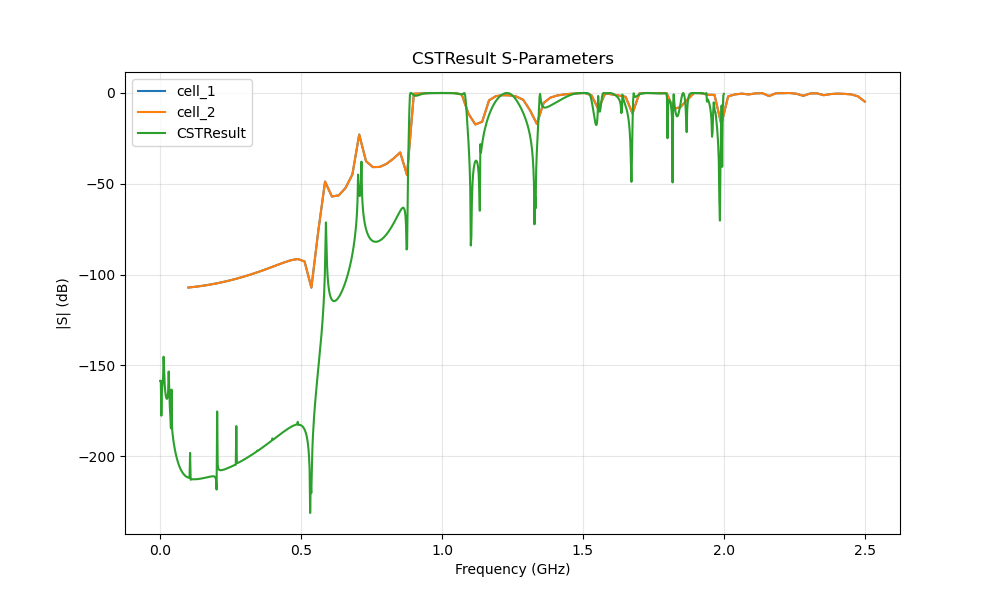

In [5]:
#import cst result
cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\pillbox')

fig, ax = project.fds.foms.plot_s(['1(1)2(1)'])
fig, ax = cstresult.plot_s(['1(1)2(1)'], ax=ax)
plt.show()

In [6]:
# project.save()

In [7]:
roms_concat = roms.concatenate()
print()
result = roms_concat.solve(0.01, 2.0, 1000)
print()
roms_concat_rom = roms_concat.reduce()
print()
result = roms_concat_rom.solve(0.01, 2.0, 1000)
print()


Coupled unified system: 605 -> 602 DOFs
  External port-modes: 6
  Internal port-modes (eliminated): 6
  Connections: 1
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\PillboxProject
FrequencyDomainSolver saved to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\PillboxProject\fds

  Solver: direct (system size 602)
  Solve: 2.603s (1000 frequencies)
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\PillboxProject
FrequencyDomainSolver saved to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\PillboxProject\fds


Reduced unified system: 602 -> 309 DOFs
  Compression: 48.7%
  Singular value decay: 9.76e+00 -> 9.62e-06

  Solver: direct (system size 309)
  Solve: 0.917s (1000 frequencies)
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\PillboxProject
FrequencyDomainSolver saved to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\PillboxProject\fds



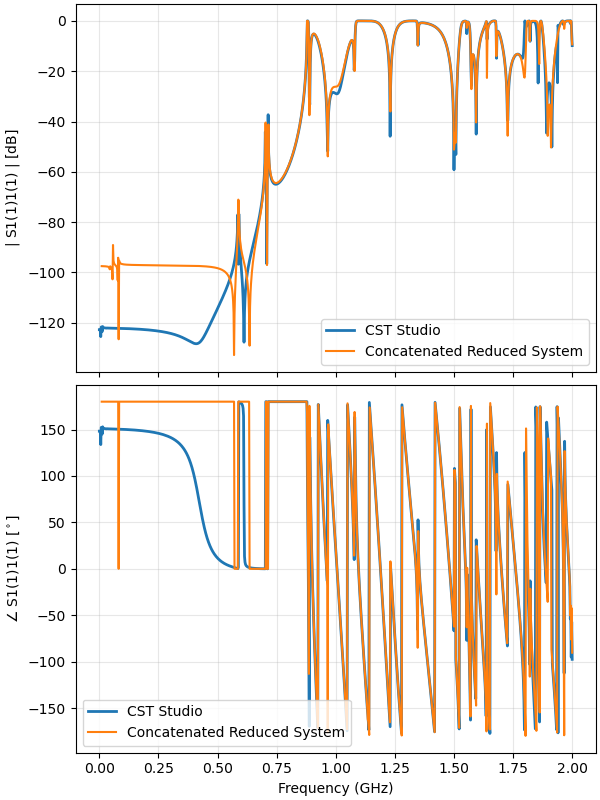

In [8]:
import matplotlib.pyplot as plt
# cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\pillbox')

# from analytical.circular_waveguide import CWGAnalytical
# radius = 150e-3  # Width: 100 mm
# L = 300e-3  # Length: 200 mm
# cstresult = CWGAnalytical(radius=radius, length=L)
which = ['1(1)1(1)']
fig, axs = plt.subplot_mosaic([[1], [3]], layout='constrained', figsize=(6,8), sharex=True)

cstresult.plot_s(['1(1)1(1)'], ax=axs[1], linewidth=2, label='CST Studio')
roms_concat.plot_s(['1(1)1(1)'], ax=axs[1], label='Concatenated Reduced System')
# roms_concat_rom.plot_s(['1(1)1(1)'], ax=axs[1])
axs[1].set_ylabel(r'$|$ S1(1)1(1) $|$ [dB]')
axs[1].set_title(r'')
axs[1].set_xlabel(r'')

cstresult.plot_s(['1(1)1(1)'], ax=axs[3], linewidth=2, plot_type='phase', label='CST Studio')
roms_concat.plot_s(['1(1)1(1)'], ax=axs[3], plot_type='phase', label='Concatenated Reduced System')
# roms_concat_rom.plot_s(['1(1)1(1)'], ax=axs[3], plot_type='phase')
axs[3].set_ylabel(r'$\angle$ S1(1)1(1) [$^\circ$]')
axs[3].set_title(r'')

# plt.savefig('pillbox_sparameter.png', dpi=300)
plt.show()

In [9]:
# from core.em_project import EMProject
# project = EMProject.load("PillboxProject", 
# base_dir=r"C:\Users\Soske\Documents\git_projects\cavsim3d_simulations")

# project.fds.foms

In [10]:
# project.fds.foms.plot_s()

In [11]:
# import matplotlib.pyplot as plt
# from analytical.cst_result import CSTResult
# cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\pillbox')

# # from analytical.circular_waveguide import CWGAnalytical
# # radius = 150e-3  # Width: 100 mm
# # L = 300e-3  # Length: 200 mm
# # cstresult = CWGAnalytical(radius=radius, length=L)
# which = ['1(1)1(1)']
# fig, axs = plt.subplot_mosaic([[1], [3]], layout='constrained', figsize=(6,8), sharex=True)

# cstresult.plot_s(['1(1)1(1)'], ax=axs[1], linewidth=2, label='CST Studio')
# project.fds.foms.roms.concat.plot_s(['1(1)1(1)'], ax=axs[1], label='Concatenated Reduced System')
# # roms_concat_rom.plot_s(['1(1)1(1)'], ax=axs[1])
# axs[1].set_ylabel(r'$|$ S1(1)1(1) $|$ [dB]')
# axs[1].set_title(r'')
# axs[1].set_xlabel(r'')

# cstresult.plot_s(['1(1)1(1)'], ax=axs[3], linewidth=2, plot_type='phase', label='CST Studio')
# project.fds.foms.roms.concat.plot_s(['1(1)1(1)'], ax=axs[3], plot_type='phase', label='Concatenated Reduced System')
# # roms_concat_rom.plot_s(['1(1)1(1)'], ax=axs[3], plot_type='phase')
# axs[3].set_ylabel(r'$\angle$ S1(1)1(1) [$^\circ$]')
# axs[3].set_title(r'')

# # plt.savefig('pillbox_sparameter.png', dpi=300)
# plt.show()